In [78]:
from keras.datasets import mnist
import numpy as np

from keras import regularizers

from keras.layers import Input
from keras.layers import Dense
from keras.layers import BatchNormalization

In [79]:
(X_train, y_train), (X_test, y_test) =  mnist.load_data()
# Data Preparation
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
# Add one more dim
from numpy import expand_dims
X_train = expand_dims(X_train, axis = -1)
X_test = expand_dims(X_test, axis = -1)
#y_train = np.reshape(y_train, (len(y_train),1))
#y_test = np.reshape(y_test, (len(y_test),1))

In [80]:
print(y_train.shape)
print(X_train.shape)

(60000,)
(60000, 28, 28, 1)


In [89]:
from keras.layers import LeakyReLU
from keras.layers import Conv2D
from keras.layers import Flatten
from keras.layers import Dropout
from keras.models import Model
from keras.activations import softmax
from keras.activations import sigmoid
from keras.optimizers import Adam

# Define discriminator models, the supervisedModel is for the labeled data, and the unsupervisedModel is for unlabeled data, they share layers
kernel_size = (3,3)
strides_size = (2,2)
input = Input(shape = (28,28,1))
# First layer
Encoder = Conv2D(128, kernel_size, padding = 'same', strides = strides_size)(input)
Encoder = LeakyReLU(alpha = 0.3)(Encoder)
# Second layer
Encoder = Conv2D(128, kernel_size, padding = 'same', strides = strides_size)(Encoder)
Encoder = LeakyReLU(alpha = 0.3)(Encoder)
# Third layer
Encoder = Conv2D(128, kernel_size, padding = 'same', strides = strides_size)(Encoder)
Encoder = LeakyReLU(alpha = 0.3)(Encoder)
# Flatten 
Encoder = Flatten()(Encoder)
# Dropout features Prevent overfitting
Encoder = Dropout(0.4)(Encoder)

# Output layer for unsupervised discriminator
outputLayer1 = Dense(1, activation='sigmoid')(Encoder)

# Output layer for supervised discriminator (output is of dim 10, 10 classes)
outputLayer2 = Dense(10, activation='softmax')(Encoder)

# Unsupervised discriminator 
unsupervisedModel = Model(input, outputLayer1)
unsupervisedModel.compile(loss = 'binary_crossentropy', 
                          optimizer = Adam(learning_rate=0.005, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=False),
                          metrics=['accuracy'])

# Supervised discriminator 
supervisedModel = Model(input, outputLayer2)
supervisedModel.compile(loss = 'sparse_categorical_crossentropy', 
                        optimizer = Adam(learning_rate=0.005, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=False),
                        metrics=['accuracy'])

In [88]:
# import some labeled dataset for the supervised training, 20 data for each class
X_labeled = []
y_labeled = []
for i in range(10):
    X_i = X_train[y_train==i]
    rand_index = np.random.randint(len(X_i), size=20)
    for index in rand_index:
        X_labeled.append(X_i[index])
        y_labeled.append(i) 
X_labeled = np.array(X_labeled)
y_labeled = np.array(y_labeled)
print(X_labeled.shape)
print(y_labeled.shape)

(200, 28, 28, 1)
(200,)


In [83]:
# generate some fake images by cutting and collapsing
# Cut the image in X_test vertically in half 
def CutHalf(x):
    height,width = x.shape
    return [x[: , :width//2] , x[:, width//2:] ]
def PasteTogether(x_1, x_2):
    height, width = x_1.shape
    x = np.zeros((height, width*2))
    x[:,width//2] = x_1
    x[:, width//2:] = x_2
    return x
# Reshape 
X_train_lowdim = np.reshape(X_train,(len(X_train), 28, 28))
# Sort X_train according to labels
index_label = np.argsort(y_train)
X_train_sorted = X_train_lowdim[index_label]
y_train_sorted = y_train[index_label]

X_train_half = np.zeros((2*len(X_train_sorted),28,14))
for i in range(0,2*len(X_train),2):
    X_train_half[i], X_train_half[i+1] = CutHalf(X_train_sorted[i//2])

X_train_fake = []
# Generate fake images by pasting unmatched figures
for i in range(10):
    # Inverse left and right for images of label i
    for j in range(0, 5000, 2):
        X_train_fake.append(np.hstack((X_train_half[12000*i+j+1],X_train_half[12000*i+j])))
    # collapse s.t. left is of label i, right is of another label
    exclude_i = np.delete(np.arange(10), i)
    for label in exclude_i:
        for j in range(0,5000, 2):
            X_train_fake.append(np.hstack((X_train_half[12000*i+j],X_train_half[12000*label+j+1])))
X_train_fake  = np.array(X_train_fake)
X_train_fake = np.reshape(X_train_fake, (len(X_train_fake), 28,28,1))
print(X_train_fake.shape)

(250000, 28, 28, 1)


In [90]:
# Train the discriminators
epoch = 10
batch_size = 200
num_batch = (len(X_train_fake)+len(X_train))//batch_size # in each epoch, we need to iter over num_batch batches of data
for e in range(epoch) :
    for i in range(num_batch):
        # Select 100 labeled datas from X_labeled (which is of size 200)
        X_classifier = []
        y_classifier = []
        rand_index = np.random.randint(200, size=100)
        for index in rand_index:
            X_classifier.append(X_labeled[index])
            y_classifier.append(y_labeled[index])
        X_classifier = np.array(X_classifier)
        y_classifier = np.array(y_classifier)

        # Train the supervised discriminator using those 100 labeled data
        supervisedModel.train_on_batch(X_classifier, y_classifier)

        # Select 100 unlabeled datas (true image) from the original dataset
        X_unlabeled = []
        rand_index = np.random.randint(len(X_train), size=100)
        for index in rand_index:
            X_unlabeled.append(X_train[index])
        X_unlabeled = np.array(X_unlabeled)    
        y_unlabeled = np.ones(100)

        # Train the unsupervised discriminator using those 100 true images
        unsupervisedModel.train_on_batch(X_unlabeled, y_unlabeled)

        # Select 200 unlabeled datas (fake image) from the fake dataset
        X_unlabeled = []
        rand_index = np.random.randint(len(X_train_fake), size=200)
        for index in rand_index:
            X_unlabeled.append(X_train_fake[index])
        X_unlabeled = np.array(X_unlabeled)    
        y_unlabeled = np.zeros(200)

        # Train the unsupervised discriminator using those 100 true images
        unsupervisedModel.train_on_batch(X_unlabeled, y_unlabeled)

    loss, accuracy = supervisedModel.evaluate(X_test, y_test, verbose=0)
    print("Epoch : ", e, ", the test accuracy for classifier is ", accuracy)

Epoch :  0 , the test accuracy for classifier is  0.7663999795913696
Epoch :  1 , the test accuracy for classifier is  0.7523000240325928
Epoch :  2 , the test accuracy for classifier is  0.7531999945640564
Epoch :  3 , the test accuracy for classifier is  0.7653999924659729
Epoch :  4 , the test accuracy for classifier is  0.7580999732017517
Epoch :  5 , the test accuracy for classifier is  0.784500002861023
Epoch :  6 , the test accuracy for classifier is  0.7508000135421753
Epoch :  7 , the test accuracy for classifier is  0.7967000007629395
Epoch :  8 , the test accuracy for classifier is  0.7800999879837036
Epoch :  9 , the test accuracy for classifier is  0.782800018787384


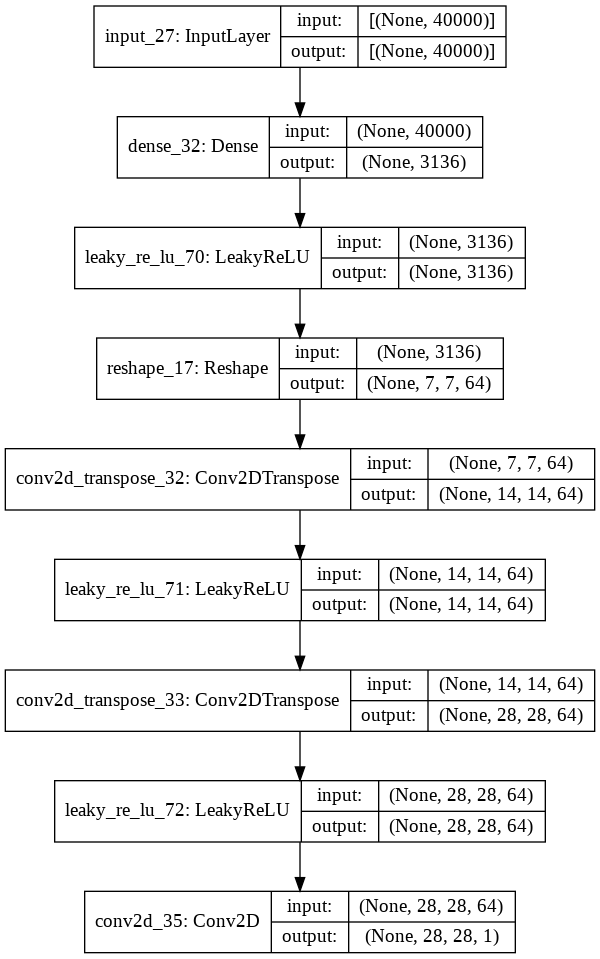

In [84]:
from keras.layers import Conv2DTranspose
from keras.layers import Reshape
from keras.utils.vis_utils import plot_model

# Define the generator, which generates a 28 x 28 image
# latent space
latentSpace = 200*200
I = Input(shape=(latentSpace,))
Dim = 64*7*7 # Number of nodes

generator = Dense(Dim)(I)
generator = LeakyReLU(alpha = 0.25)(generator)
generator = Reshape((7,7,64))(generator)

generator = Conv2DTranspose(64, kernel_size, padding = 'same', strides = strides_size)(generator)
generator = LeakyReLU(alpha = 0.18)(generator)
generator = Conv2DTranspose(64, kernel_size, padding = 'same', strides = strides_size)(generator)
generator = LeakyReLU(alpha = 0.18)(generator)

# Output layer
outputLayer3 = Conv2D(1,kernel_size, padding = 'same', activation = 'sigmoid')(generator)
generatorModel = Model(I, outputLayer3)

# Plot the generator
plot_model(generatorModel,show_shapes=True)

In [85]:
# Combine the generator with the unsupervised discriminator, where the input is the input of generator, the output is a binary label
def comb_generator(generator, unsupervisedModel, generator_input, generator_output):
    unsupervisedModel.trainable = False
    outputLayer4 = unsupervisedModel(generator_output)
    combination = Model(generator_input, outputLayer4)
    combination.compile(loss = 'binary_crossentropy', 
                        optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=False),
                        metrics=['accuracy'])
    return combination

generator_discriminator = comb_generator(generator, unsupervisedModel, I, outputLayer3)

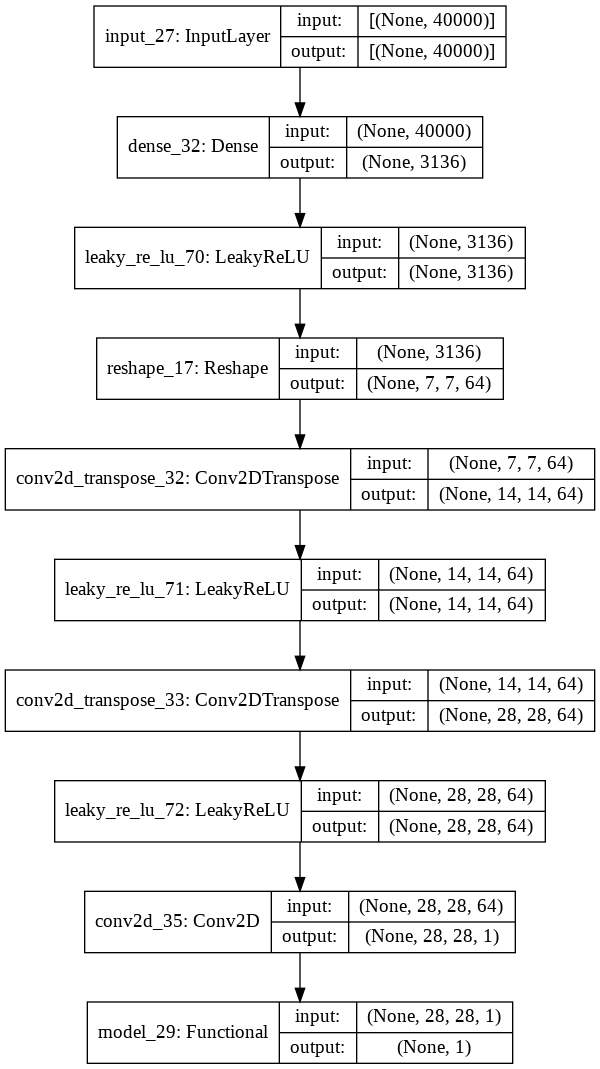

In [86]:
plot_model(generator_discriminator,show_shapes=True)